# Modeling Supreme Court Case Outcomes
### DTSC 2301 — Portfolio Project Two

This notebook picks up from `01_data_cleaning_eda.ipynb` using the cleaned,
scoped dataset (`scdb_cleaned_2000_2025.csv`, 1,949 cases, terms 2000-2025).

Covers: train/test split, baseline, two models (logistic regression and random
forest), evaluation, and interpretation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, RocCurveDisplay
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load the cleaned data

In [2]:
df = pd.read_csv("scdb_cleaned_2000_2025.csv")
print(f"{df.shape[0]:,} cases, {df.shape[1]} columns")

categorical_features = [
    "issueArea", "petitioner", "respondent", "jurisdiction",
    "caseOrigin", "caseSource", "lcDisagreement", "certReason",
    "lcDispositionDirection", "threeJudgeFdc", "chief",
]
numeric_features = ["term"]

X = df[categorical_features + numeric_features].copy()
# SCDB categorical fields are stored as numeric codes -- cast to string so
# they are one-hot encoded as categories, not treated as ordered numbers.
for c in categorical_features:
    X[c] = X[c].apply(lambda v: str(v) if pd.notna(v) else np.nan)

y = df["partyWinning"]
X.head()

1,949 cases, 14 columns


,issueArea,petitioner,respondent,jurisdiction,caseOrigin,caseSource,lcDisagreement,certReason,lcDispositionDirection,threeJudgeFdc,chief,term
0,2.0,28.0,28.0,9.0,NaN,NaN,0.0,1.0,NaN,0.0,Rehnquist,2000
1,1.0,28.0,137.0,1.0,94.0,22.0,0.0,12.0,2.0,0.0,Rehnquist,2000
2,1.0,177.0,27.0,1.0,75.0,25.0,0.0,2.0,2.0,0.0,Rehnquist,2000
3,9.0,251.0,251.0,2.0,41.0,41.0,0.0,1.0,2.0,1.0,Rehnquist,2000
4,1.0,3.0,214.0,1.0,69.0,27.0,0.0,12.0,2.0,0.0,Rehnquist,2000


## 2. Train / test split

We use a stratified random 80/20 split, which preserves the ~68.5% / 31.5%
class balance in both sets. A random split is appropriate here because our
research questions are about which case characteristics predict the outcome
in general, not about forecasting future terms specifically — but it's worth
naming as a limitation: a model trained on a random split could still be
"peeking" at patterns from later terms when predicting earlier ones. A
time-based split (train on 2000-2019, test on 2020-2025) is a reasonable
alternative and is revisited briefly at the end of this notebook as an
extension.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} cases | Test: {X_test.shape[0]:,} cases")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train: 1,559 cases | Test: 390 cases

Train class balance:
partyWinning
1    0.686
0    0.314
Name: proportion, dtype: float64

Test class balance:
partyWinning
1    0.685
0    0.315
Name: proportion, dtype: float64


## 3. Preprocessing pipeline

- Categorical features: missing values filled with a `"missing"` category
  (informative in this data, since missingness often reflects a case type
  where a field doesn't apply), then one-hot encoded.
- Numeric feature (`term`): missing values (none expected) filled with the
  median, then standardized.

Wrapping this in a `ColumnTransformer` + `Pipeline` means the same
preprocessing is fit on the training data only and then applied unchanged to
the test data, which avoids leaking test-set information into preprocessing.

In [4]:
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("cat", categorical_pipe, categorical_features),
    ("num", numeric_pipe, numeric_features),
])

## 4. Baseline

The baseline always predicts the majority class (petitioner wins). Any model
we build needs to clear this bar -- and clear it on precision/recall/F1 for
the minority class, not just accuracy, since a model that always predicts
"petitioner wins" would already score well on accuracy alone.

In [5]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

def report(name, y_true, y_pred, y_proba=None):
    row = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        row["roc_auc"] = roc_auc_score(y_true, y_proba)
    return row

results = [report("Baseline (majority class)", y_test, baseline_pred)]
pd.DataFrame(results).round(3)

,model,accuracy,precision,recall,f1
0,Baseline (majority class),0.685,0.685,1.0,0.813


## 5. Model 1: Logistic Regression

Chosen because the outcome is binary and logistic regression produces
coefficients that translate directly into odds ratios -- useful for
explaining *why* the model predicts what it predicts, which matters for the
interpretation section below.

In [6]:
logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

results.append(report("Logistic Regression", y_test, logreg_pred, logreg_proba))
pd.DataFrame(results).round(3)

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline (majority class),0.685,0.685,1.000,0.813,NaN
1,Logistic Regression,0.662,0.705,0.869,0.779,0.609


## 6. Model 2: Random Forest

Chosen because it can capture interactions between categorical features
(for example, issue area combined with lower court direction) without those
interactions being specified by hand, and it provides a feature-importance
ranking as a second, independent way to interpret the model.

In [7]:
rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        random_state=RANDOM_STATE, class_weight="balanced"
    )),
])

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

results.append(report("Random Forest", y_test, rf_pred, rf_proba))
results_df = pd.DataFrame(results).round(3)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline (majority class),0.685,0.685,1.000,0.813,NaN
1,Logistic Regression,0.662,0.705,0.869,0.779,0.609
2,Random Forest,0.608,0.766,0.614,0.682,0.644


**Note on `class_weight="balanced"`:** the random forest is set to weight
the minority class (petitioner loses) more heavily during training. Without
this, a model can lean on the ~69% base rate and under-predict the minority
class -- which would look fine on accuracy but poorly on recall for that
class. This choice is a modeling decision worth explaining in the writeup.

## 7. Comparing models

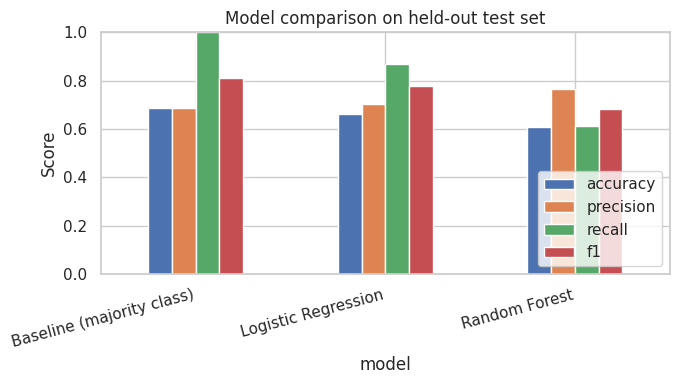

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = results_df.set_index("model")[["accuracy", "precision", "recall", "f1"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Model comparison on held-out test set")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("fig_model_comparison.png", dpi=150)
plt.show()

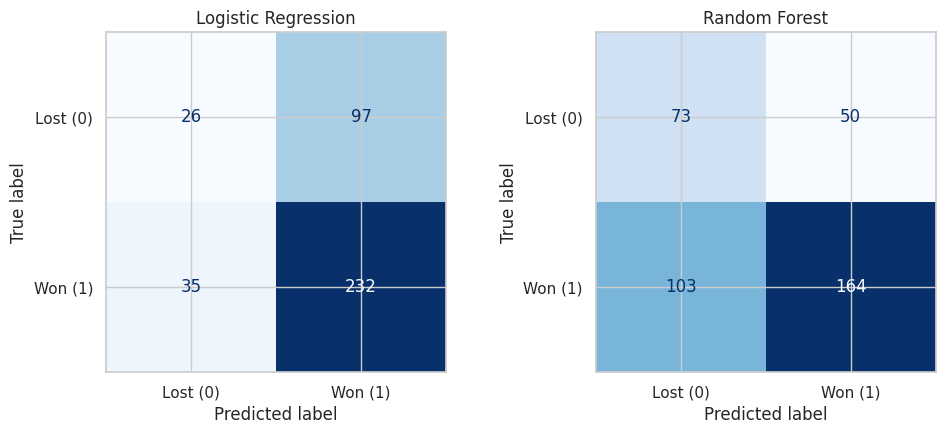

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (name, pred) in zip(axes, [("Logistic Regression", logreg_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Lost (0)", "Won (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=150)
plt.show()

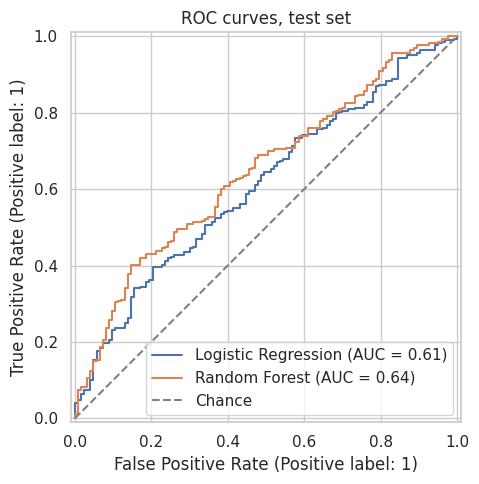

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, logreg_proba, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC curves, test set")
ax.legend()
plt.tight_layout()
plt.savefig("fig_roc_curves.png", dpi=150)
plt.show()

## 8. Model interpretation

### 8a. Logistic regression coefficients (odds ratios)

A coefficient greater than 1 (as an odds ratio) means that feature is
associated with a *higher* chance the petitioner wins, holding the other
features fixed; less than 1 means a *lower* chance.

In [11]:
feature_names = logreg.named_steps["prep"].get_feature_names_out()
coefs = logreg.named_steps["clf"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    .assign(odds_ratio=lambda d: np.exp(d.coefficient))
    .sort_values("coefficient")
)

print("Strongest coefficients associated with the petitioner LOSING:")
display(coef_df.head(10))

print("\nStrongest coefficients associated with the petitioner WINNING:")
display(coef_df.tail(10))

Strongest coefficients associated with the petitioner LOSING:


,feature,coefficient,odds_ratio
271,cat__respondent_187.0,-1.509679,0.220981
14,cat__issueArea_missing,-1.359704,0.256737
176,cat__petitioner_394.0,-1.309384,0.269986
546,cat__certReason_1.0,-1.215234,0.296641
220,cat__respondent_130.0,-1.176250,0.308433
114,cat__petitioner_216.0,-1.135655,0.321212
174,cat__petitioner_382.0,-1.042815,0.352461
482,cat__caseOrigin_82.0,-1.025723,0.358537
66,cat__petitioner_158.0,-0.968937,0.379486
18,cat__petitioner_102.0,-0.940512,0.390428



Strongest coefficients associated with the petitioner WINNING:


,feature,coefficient,odds_ratio
343,cat__respondent_343.0,0.921302,2.512559
441,cat__caseOrigin_44.0,0.926234,2.524983
54,cat__petitioner_145.0,0.945985,2.575350
26,cat__petitioner_113.0,0.998914,2.715331
396,cat__caseOrigin_116.0,1.015119,2.759692
35,cat__petitioner_124.0,1.027957,2.795348
237,cat__respondent_150.0,1.030485,2.802425
446,cat__caseOrigin_49.0,1.033975,2.812221
552,cat__certReason_3.0,1.098773,3.000481
384,cat__caseOrigin_104.0,1.236801,3.444576


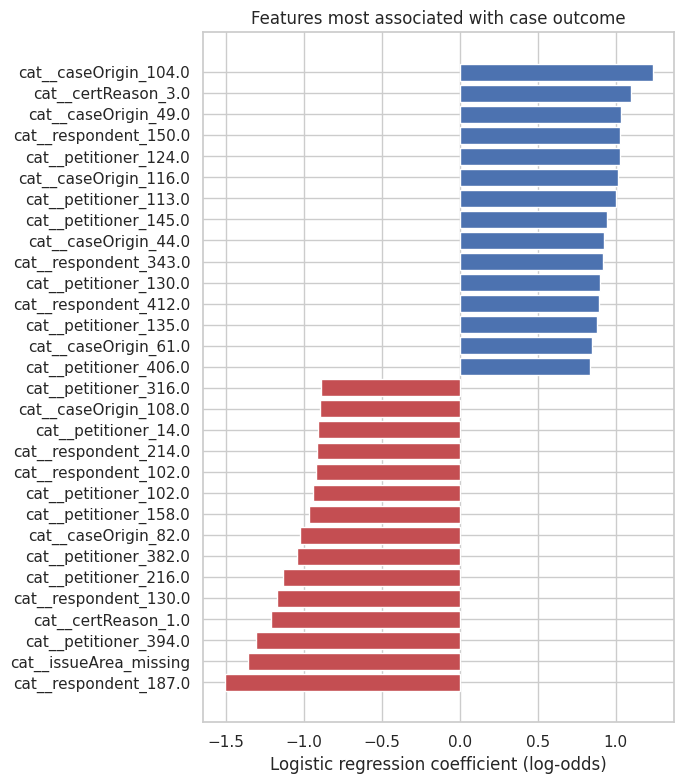

In [12]:
top_n = 15
plot_coefs = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)])
fig, ax = plt.subplots(figsize=(7, 8))
colors = ["#c44e52" if v < 0 else "#4c72b0" for v in plot_coefs.coefficient]
ax.barh(plot_coefs.feature, plot_coefs.coefficient, color=colors)
ax.set_xlabel("Logistic regression coefficient (log-odds)")
ax.set_title("Features most associated with case outcome")
plt.tight_layout()
plt.savefig("fig_logreg_coefficients.png", dpi=150)
plt.show()

### 8b. Random forest feature importance

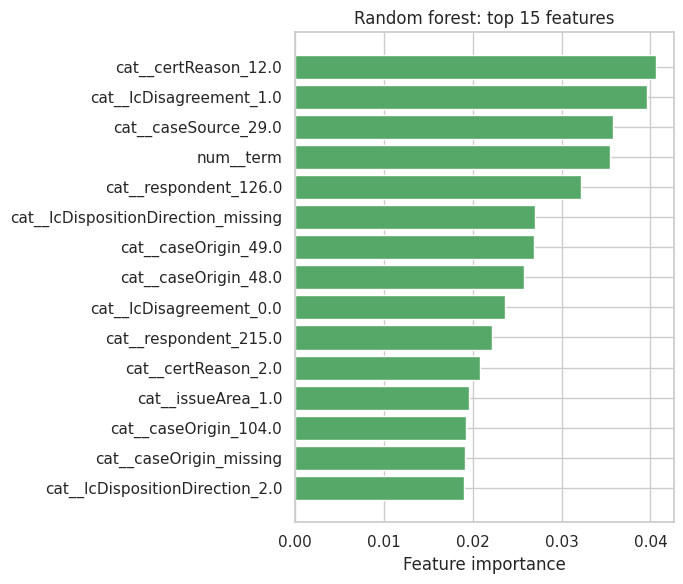

,feature,importance
549,cat__certReason_12.0,0.040625
544,cat__lcDisagreement_1.0,0.039635
520,cat__caseSource_29.0,0.035807
569,num__term,0.035503
216,cat__respondent_126.0,0.032188
563,cat__lcDispositionDirection_missing,0.026958
446,cat__caseOrigin_49.0,0.026856
445,cat__caseOrigin_48.0,0.025751
543,cat__lcDisagreement_0.0,0.023612
291,cat__respondent_215.0,0.022211


In [13]:
rf_importances = pd.DataFrame({
    "feature": rf.named_steps["prep"].get_feature_names_out(),
    "importance": rf.named_steps["clf"].feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
top = rf_importances.head(15)
ax.barh(top.feature[::-1], top.importance[::-1], color="#55a868")
ax.set_xlabel("Feature importance")
ax.set_title("Random forest: top 15 features")
plt.tight_layout()
plt.savefig("fig_rf_importance.png", dpi=150)
plt.show()

rf_importances.head(15)

### 8c. Error analysis

A look at cases the random forest got most confidently wrong -- these are
useful examples for the Model Interpretation and Limitations sections of the
writeup.

In [14]:
error_df = X_test.copy()
error_df["true_label"] = y_test.values
error_df["predicted_proba_win"] = rf_proba
error_df["predicted_label"] = rf_pred
error_df["case_id"] = df.loc[X_test.index, "caseId"].values

misclassified = error_df[error_df.true_label != error_df.predicted_label].copy()
misclassified["confidence"] = np.where(
    misclassified.predicted_label == 1,
    misclassified.predicted_proba_win,
    1 - misclassified.predicted_proba_win,
)
misclassified.sort_values("confidence", ascending=False).head(10)[
    ["case_id", "issueArea", "chief", "true_label", "predicted_label", "confidence"]
]

,case_id,issueArea,chief,true_label,predicted_label,confidence
746,2009-014,11.0,Roberts,1,0,0.694509
0,2000-001,2.0,Rehnquist,1,0,0.683881
181,2002-011,8.0,Rehnquist,0,1,0.653608
205,2002-035,4.0,Rehnquist,0,1,0.592697
1190,2014-055,3.0,Roberts,0,1,0.588631
307,2003-065,1.0,Rehnquist,0,1,0.588437
1454,2018-015,9.0,Roberts,0,1,0.571290
1517,2019-006,10.0,Roberts,1,0,0.568680
411,2004-078,3.0,Rehnquist,0,1,0.566881
1376,2017-013,8.0,Roberts,0,1,0.564872


## 9. Summary of results

In [15]:
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline (majority class),0.685,0.685,1.000,0.813,NaN
1,Logistic Regression,0.662,0.705,0.869,0.779,0.609
2,Random Forest,0.608,0.766,0.614,0.682,0.644


**Reading the comparison:** both models should be compared against the
baseline first -- beating ~69% accuracy alone is not a high bar given the
class imbalance, so the precision/recall/F1 columns for the minority class
matter more. Fill in the specific numbers from the table above when writing
the Model Evaluation section, and use the ROC-AUC to discuss which model
ranks cases better overall, independent of the classification threshold.

## 10. Possible extension: time-based split

As noted above, a time-based split (train on earlier terms, test on the most
recent ones) is a stronger test of real-world usefulness than a random split,
since in practice you'd want to predict *future* cases, not interpolate
within a random shuffle. This is left as an optional extension for the
Technical Depth and Originality section -- rerunning the pipeline above with
`train = df[df.term <= 2019]` and `test = df[df.term > 2019]` and comparing
the results is a natural next step if time allows.